In [1]:
import sys
import os
import joblib
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date

sys.path.append(os.path.abspath('..'))

from ext.portfolio_math import (
    estimate_expected_returns,
    estimate_covariance_matrix,
    mean_variance_cost,
    target_return_cost,
    add_risk_free_asset,
    enforce_portfolio_constraints
)

from ext.sgd_optimizer import run_sgd, initialize_weights
from ext.portfolio_backtest import run_portfolio_backtest
from ext.ml_signals import build_ml_signals, build_features, build_target
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

In [2]:
# ============================================================
# 1. DONNÉES CAC 40
# ============================================================

tickers = ["TTE.PA", "SAN.PA", "BNP.PA", "AIR.PA", "MC.PA",
           "OR.PA",  "SU.PA",  "DG.PA",  "RI.PA",  "KER.PA"]

# (Aujourd'hui moins 4 mois)
date_fin_train = pd.Timestamp.now() - pd.DateOffset(months=4)
TODAY = date.today().strftime("%Y-%m-%d")


raw = yf.download(tickers, start="2020-01-01", end=TODAY, auto_adjust=True)
prices_all = raw["Close"].dropna()
returns_all = prices_all.pct_change().dropna()

prices = prices_all.loc[:date_fin_train]
returns = returns_all.loc[:date_fin_train]

print(f"Période : {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"Actifs  : {list(returns.columns)}")
print(f"Jours   : {len(returns)}")

[*********************100%***********************]  10 of 10 completed

Période : 2020-01-03 → 2026-01-02
Actifs  : ['AIR.PA', 'BNP.PA', 'DG.PA', 'KER.PA', 'MC.PA', 'OR.PA', 'RI.PA', 'SAN.PA', 'SU.PA', 'TTE.PA']
Jours   : 1538


In [3]:
# ============================================================
# 2. PARAMÈTRES MARCHÉ
# ============================================================

mu    = estimate_expected_returns(returns)
Sigma = estimate_covariance_matrix(returns)

risk_free_rate_annual = 0.02
risk_free_rate_daily  = risk_free_rate_annual / 252

print(f"Rendement moyen (annualisé) : {mu.mean() * 252:.2%}")
print(f"Taux sans risque journalier : {risk_free_rate_daily:.6f}")

Rendement moyen (annualisé) : 9.84%
Taux sans risque journalier : 0.000079


Poids optimisés (mean-variance) :
  TTE.PA   : 0.0000
  SAN.PA   : 0.1166
  BNP.PA   : 0.0000
  AIR.PA   : 0.0000
  MC.PA    : 0.0000
  OR.PA    : 0.1035
  SU.PA    : 0.0000
  DG.PA    : 0.1410
  RI.PA    : 0.5305
  KER.PA   : 0.1083


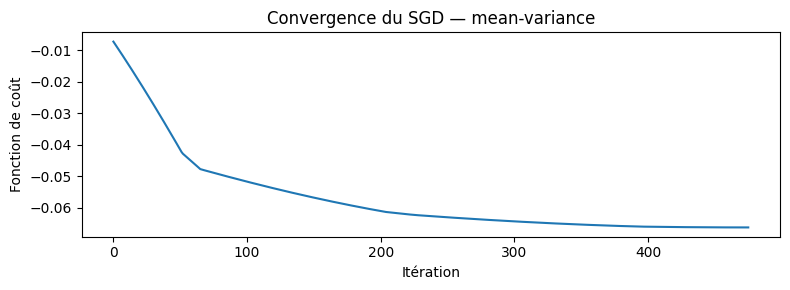

In [4]:
# ============================================================
# 3a. OPTIMISATION PAR SGD (mean-variance)
# ============================================================

n_assets = len(tickers)
initial_weights = initialize_weights(n_assets, method="equal")

sgd_results = run_sgd(
    cost_function=mean_variance_cost,
    initial_weights=initial_weights,
    n_iterations=500,
    learning_rate=0.01,
    constraint_function=enforce_portfolio_constraints,
    expected_returns=mu,
    covariance_matrix=Sigma,
    lambda_risk=2.0,
)

optimized_weights = sgd_results["final_weights"]

print("Poids optimisés (mean-variance) :")
for ticker, w in zip(tickers, optimized_weights):
    print(f"  {ticker:8s} : {w:.4f}")

plt.figure(figsize=(8, 3))
plt.plot(sgd_results["cost_history"])
plt.title("Convergence du SGD — mean-variance")
plt.xlabel("Itération")
plt.ylabel("Fonction de coût")
plt.tight_layout()
plt.show()

Poids optimisés (rendement cible 8%) :
  TTE.PA   : 0.1000
  SAN.PA   : 0.1000
  BNP.PA   : 0.1000
  AIR.PA   : 0.1000
  MC.PA    : 0.1000
  OR.PA    : 0.1000
  SU.PA    : 0.1000
  DG.PA    : 0.1000
  RI.PA    : 0.1000
  KER.PA   : 0.1000


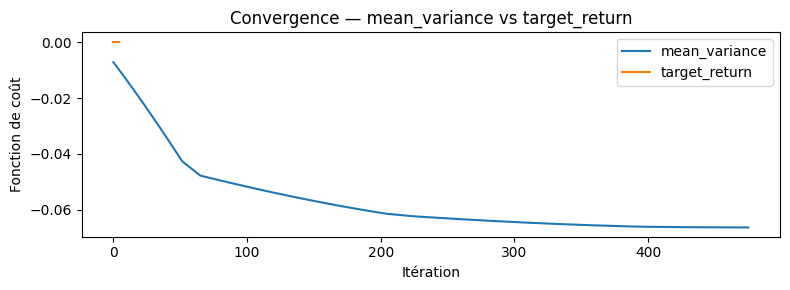

In [5]:
# ============================================================
# 3b. OPTIMISATION AVEC RENDEMENT CIBLE (target_return_cost)
# ============================================================

target_return_daily = 0.08 / 252  # 8% annualisé

sgd_results_target = run_sgd(
    cost_function=target_return_cost,
    initial_weights=initialize_weights(n_assets, method="equal"),
    n_iterations=500,
    learning_rate=0.01,
    constraint_function=enforce_portfolio_constraints,
    expected_returns=mu,
    covariance_matrix=Sigma,
    target_return=target_return_daily,
    alpha=10,
)

optimized_weights_target = sgd_results_target["final_weights"]

print("Poids optimisés (rendement cible 8%) :")
for ticker, w in zip(tickers, optimized_weights_target):
    print(f"  {ticker:8s} : {w:.4f}")

# Comparaison des convergences
plt.figure(figsize=(8, 3))
plt.plot(sgd_results["cost_history"], label="mean_variance")
plt.plot(sgd_results_target["cost_history"], label="target_return")
plt.title("Convergence — mean_variance vs target_return")
plt.xlabel("Itération")
plt.ylabel("Fonction de coût")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# 3c. OPTIMISATION AVEC ACTIF SANS RISQUE (add_risk_free_asset)
# ============================================================

mu_rf, Sigma_rf = add_risk_free_asset(mu, Sigma, risk_free_rate_daily)

n_assets_rf = n_assets + 1
initial_weights_rf = initialize_weights(n_assets_rf, method="equal")

sgd_results_rf = run_sgd(
    cost_function=mean_variance_cost,
    initial_weights=initial_weights_rf,
    n_iterations=500,
    learning_rate=0.01,
    constraint_function=enforce_portfolio_constraints,
    expected_returns=mu_rf,
    covariance_matrix=Sigma_rf,
    lambda_risk=2.0,
)

optimized_weights_rf = sgd_results_rf["final_weights"]

print("Poids optimisés (avec actif sans risque) :")
for ticker, w in zip(tickers + ["Risk-Free"], optimized_weights_rf):
    print(f"  {ticker:12s} : {w:.4f}")
print(f"\nPoids alloué à l'actif sans risque : {optimized_weights_rf[-1]:.2%}")

Poids optimisés (avec actif sans risque) :
  TTE.PA       : 0.0000
  SAN.PA       : 0.1300
  BNP.PA       : 0.0000
  AIR.PA       : 0.0000
  MC.PA        : 0.0272
  OR.PA        : 0.0703
  SU.PA        : 0.0000
  DG.PA        : 0.0621
  RI.PA        : 0.3579
  KER.PA       : 0.0915
  Risk-Free    : 0.2610

Poids alloué à l'actif sans risque : 26.10%


In [7]:
# ============================================================
# 4. SIGNAUX ML — PIPELINE SIMPLE
# ============================================================

ml_results = build_ml_signals(
    price_data=prices,
    returns_data=returns,
    window=20,
    method="momentum_volatility",
    long_only=True
)

dynamic_weights_signal = ml_results["weights_for_backtest"]
returns_signal = ml_results["returns_for_backtest"]

print(f"Dates disponibles pour le backtest dynamique : {len(dynamic_weights_signal)}")

Dates disponibles pour le backtest dynamique : 1538


In [8]:
def flatten_features(features_dict):
    """
    Transforme le dictionnaire de features en un seul DataFrame compatible ML.
    """
    feature_tables = []

    for feature_name, df in features_dict.items():
        df_named = df.copy()
        df_named.columns = [f"{col}_{feature_name}" for col in df.columns]
        feature_tables.append(df_named)

    X = pd.concat(feature_tables, axis=1)
    X = X.replace([np.inf, -np.inf], np.nan).dropna()

    return X

In [9]:
prices_test = prices_all.loc[date_fin_train:]
returns_test = returns_all.loc[date_fin_train:]

# Génération des signaux ML sur les données de test uniquement
ml_test_results = build_ml_signals(
    price_data=prices_test,
    returns_data=returns_test,
    window=20,
    method="momentum_volatility",
    long_only=True
)

# On récupère les poids dynamiques générés par le ML pour le test
dynamic_weights_test = ml_test_results["weights_for_backtest"]
returns_test_aligned = ml_test_results["returns_for_backtest"]

In [10]:
# ============================================================
# 6. ENTRAÎNEMENT FINAL SUR TOUTES LES DONNÉES
#    → modèle sauvegardé pour prédiction dans 2-3 mois
# ============================================================

test_backtest_results = run_portfolio_backtest(
    returns_matrix=returns_test_aligned,
    optimized_weights=optimized_weights, # Poids issus de l'entraînement
    dynamic_weights=dynamic_weights_test,
    initial_value=1.0,
    risk_free_rate=risk_free_rate_daily
)

print("\n--- PERFORMANCE RÉELLE SUR LES 4 DERNIERS MOIS ---")
print(test_backtest_results["comparison"])


--- PERFORMANCE RÉELLE SUR LES 4 DERNIERS MOIS ---
              cumulative_return  volatility  theoretical_volatility  \
equal_weight          -0.017027    0.182635                0.182635   
optimized              0.123265    0.225566                0.225566   
dynamic                0.060525    0.205394                     NaN   

              sharpe_ratio  max_drawdown  
equal_weight     -0.146753     -0.112129  
optimized         1.707487     -0.107591  
dynamic           1.041217     -0.096295  


[*********************100%***********************]  1 of 1 completed


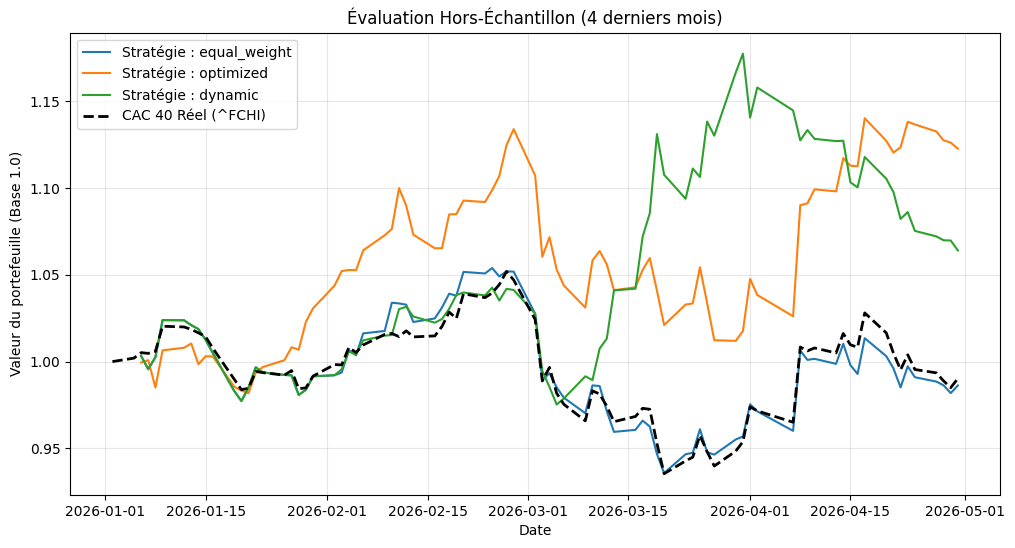

In [11]:
# ============================================================
# 7. BACKTEST COMPLET
# ============================================================

plt.figure(figsize=(12, 6))

# Récupération de la valeur du CAC 40 réel pour la comparaison
cac40_test = yf.download("^FCHI", start=date_fin_train, end=TODAY, auto_adjust=True)["Close"]
cac40_norm = cac40_test / cac40_test.iloc[0]

# Tracé des stratégies
for name, res in test_backtest_results["strategy_results"].items():
    plt.plot(res["portfolio_value"], label=f"Stratégie : {name}")

# Tracé du CAC 40
plt.plot(cac40_norm, label="CAC 40 Réel (^FCHI)", color="black", linestyle="--", linewidth=2)

plt.title(f"Évaluation Hors-Échantillon (4 derniers mois)")
plt.xlabel("Date")
plt.ylabel("Valeur du portefeuille (Base 1.0)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

[*********************100%***********************]  1 of 1 completed


NameError: name 'backtest' is not defined

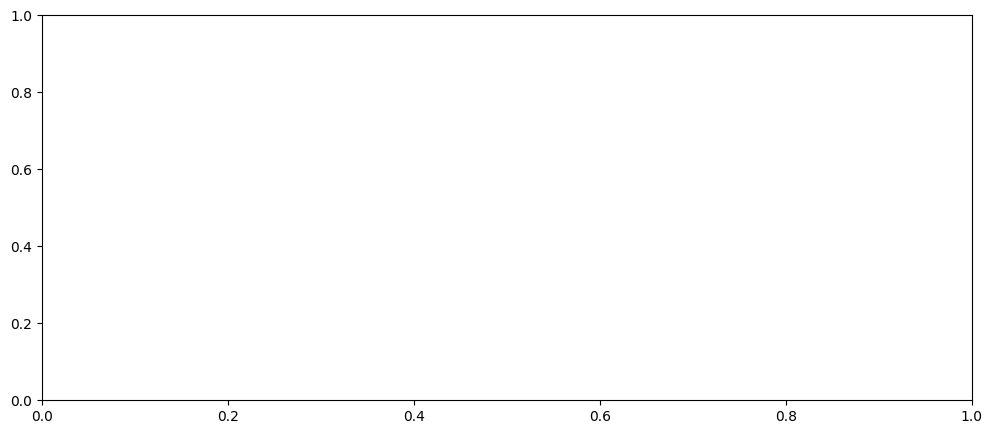

In [12]:
# ============================================================
# 8. VISUALISATION
# ============================================================

cac40            = yf.download("^FCHI", start="2020-01-01", end=TODAY, auto_adjust=True)["Close"]
cac40_normalized = cac40 / cac40.iloc[0]

fig, ax = plt.subplots(figsize=(12, 5))

for name, res in backtest["strategy_results"].items():
    res["portfolio_value"].plot(ax=ax, label=name)

cac40_normalized.plot(ax=ax, label="^FCHI", color="black", linestyle="--", linewidth=1.5)

ax.set_title(f"Walk-Forward — CAC 40 (entraîné jusqu'au {TODAY})")
ax.set_ylabel("Valeur du portefeuille (base 1)")
ax.axhline(1, color="gray", linestyle=":", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# 9. PRÉVISION SUR 2 MOIS (basée sur les rendements historiques)
# ============================================================

HORIZON_DAYS = 42  # ~2 mois de trading

# --- Signal prédit sur les dernières features connues ---
# On prend les 20 derniers jours de features (fenêtre glissante)
# et on prédit le signal pour chaque jour futur simulé
last_features = X_full.tail(20)
last_features_sc = scaler_final.transform(last_features)
last_signal = model_final.predict(last_features_sc)

# Signal majoritaire sur les 20 derniers jours → signal futur attendu
signal_futur = int(pd.Series(last_signal).mode()[0])
print(f"Signal prédit pour les {HORIZON_DAYS} prochains jours : {signal_futur}")
print(f"  (1 = investir avec poids optimisés, -1 = désinvestir/cash)")

# --- Rendements futurs simulés via bootstrap historique ---
# On tire aléatoirement HORIZON_DAYS jours dans les rendements passés
# C'est une simulation non-paramétrique qui préserve les corrélations réelles
np.random.seed(42)
sampled_idx     = np.random.choice(len(returns), size=HORIZON_DAYS, replace=True)
returns_simul   = returns.iloc[sampled_idx].reset_index(drop=True)

# Dates futures simulées (jours ouvrés)
future_dates = pd.bdate_range(start=TODAY, periods=HORIZON_DAYS)
returns_simul.index = future_dates

# --- CORRECTION : Poids dynamiques futurs selon le signal prédit ---
dynamic_weights_future = pd.DataFrame(0.0, index=future_dates, columns=tickers)

for date in future_dates:
    if signal_futur > 0:
        # Marché haussier -> On utilise les poids optimisés par SGD
        dynamic_weights_future.loc[date] = optimized_weights
    else:
        # Marché baissier -> On se met en cash (0%) pour éviter le drawdown
        dynamic_weights_future.loc[date] = 0.0

# --- Simulation des 3 stratégies sur la période future ---
backtest_future = run_portfolio_backtest(
    returns_matrix=returns_simul,
    optimized_weights=optimized_weights,
    dynamic_weights=dynamic_weights_future,
    initial_value=1.0,
    risk_free_rate=risk_free_rate_daily,
)

print(f"\nPerformance simulée sur {HORIZON_DAYS} jours futurs :")
print(backtest_future["comparison"].to_string())

# --- Visualisation : historique réel + projection future ---
fig, ax = plt.subplots(figsize=(14, 5))

# Historique réel (derniers 6 mois pour la lisibilité)
cutoff = pd.Timestamp(TODAY) - pd.DateOffset(months=6)
for name, res in backtest["strategy_results"].items():
    hist = res["portfolio_value"]
    hist_recent = hist[hist.index >= cutoff]
    # Normaliser pour que la jonction parte de 1.0
    hist_recent = hist_recent / hist_recent.iloc[-1]
    hist_recent.plot(ax=ax, label=f"{name} (historique)")

# Projection future
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, (name, res) in enumerate(backtest_future["strategy_results"].items()):
    proj = res["portfolio_value"]
    proj.plot(ax=ax, linestyle="--", color=colors[i], label=f"{name} (projection)")

# Ligne de séparation aujourd'hui
ax.axvline(pd.Timestamp(TODAY), color="red", linestyle=":", linewidth=1.5, label="Aujourd'hui")
ax.axhline(1, color="gray", linestyle=":", linewidth=0.8)
ax.set_title(f"Historique récent + Projection {HORIZON_DAYS}j — Signal prédit : {signal_futur}")
ax.set_ylabel("Valeur du portefeuille (base 1)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("\nRemarque : la projection est basée sur un bootstrap des rendements historiques.")
print("Elle représente un scénario probable, pas une garantie.")

NameError: name 'X_full' is not defined